In [75]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/airport_disruptions.csv
/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/flight_cancellations.csv
/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/airspace_closures.csv
/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/conflict_events.csv
/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/flight_reroutes.csv
/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/airline_losses_estimate.csv


## Import Required Libraries

In [76]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import shap

sns.set_style("whitegrid")


In [77]:
airport = pd.read_csv("/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/airport_disruptions.csv")
cancel = pd.read_csv("/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/flight_cancellations.csv")
airspace = pd.read_csv("/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/airspace_closures.csv")
events = pd.read_csv("/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/conflict_events.csv")
reroute = pd.read_csv("/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/flight_reroutes.csv")
loss = pd.read_csv("/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/airline_losses_estimate.csv")

print("Datasets Loaded")
print("Airport:", airport.shape)
print("Cancellations:", cancel.shape)
print("Airspace:", airspace.shape)
print("Events:", events.shape)
print("Reroutes:", reroute.shape)
print("Loss:", loss.shape)

Datasets Loaded
Airport: (35, 10)
Cancellations: (50, 9)
Airspace: (25, 7)
Events: (28, 9)
Reroutes: (45, 7)
Loss: (35, 7)


In [78]:
loss = loss.dropna()

## VISUALIZATIONS

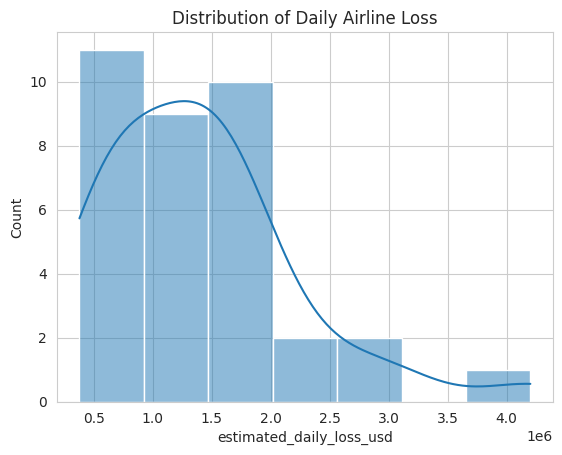

In [79]:
plt.figure()
sns.histplot(loss["estimated_daily_loss_usd"], kde=True)
plt.title("Distribution of Daily Airline Loss")
plt.show()

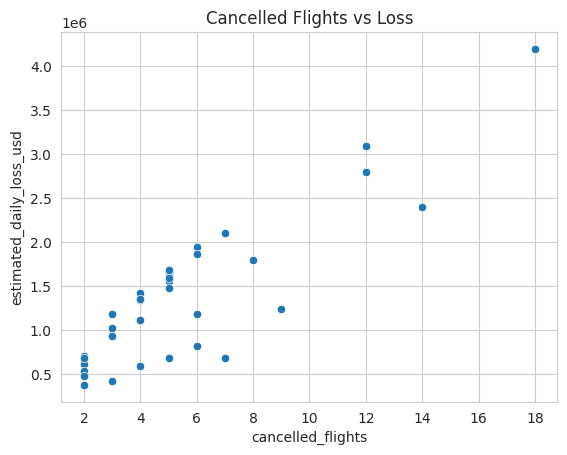

In [80]:
plt.figure()
sns.scatterplot(x=loss["cancelled_flights"],y=loss["estimated_daily_loss_usd"])
plt.title("Cancelled Flights vs Loss")
plt.show()

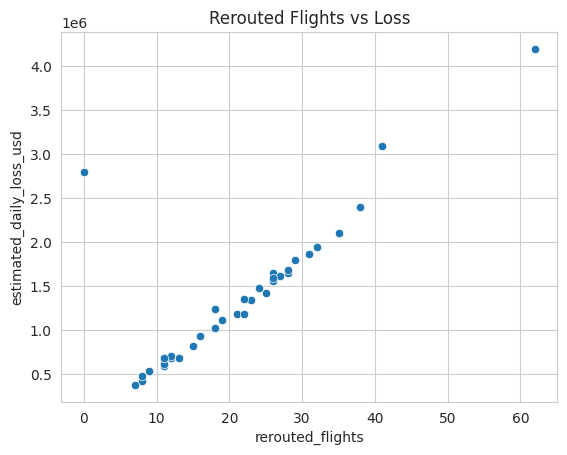

In [81]:
plt.figure()
sns.scatterplot(x=loss["rerouted_flights"],y=loss["estimated_daily_loss_usd"])
plt.title("Rerouted Flights vs Loss")
plt.show()

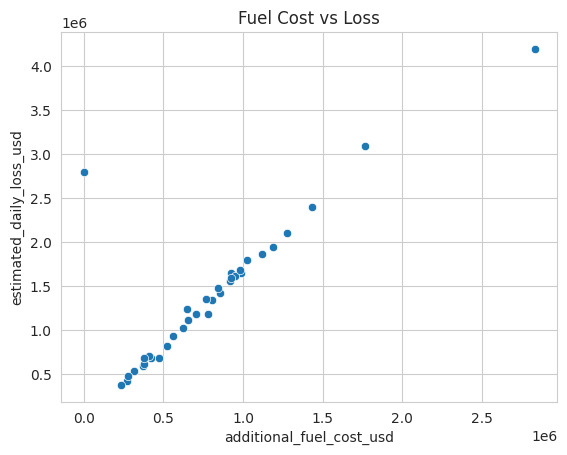

In [82]:
plt.figure()
sns.scatterplot(x=loss["additional_fuel_cost_usd"],y=loss["estimated_daily_loss_usd"])
plt.title("Fuel Cost vs Loss")
plt.show()

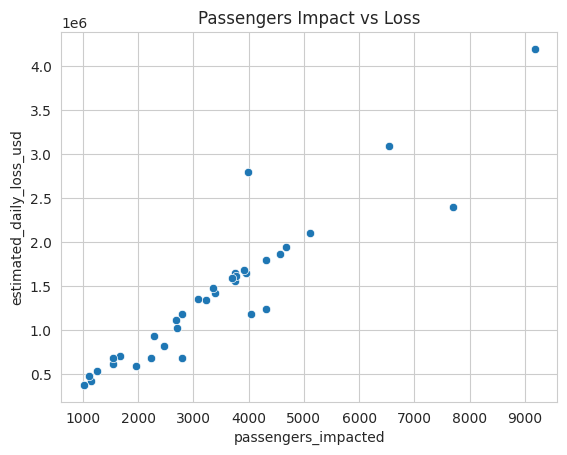

In [83]:
plt.figure()
sns.scatterplot(x=loss["passengers_impacted"],y=loss["estimated_daily_loss_usd"])
plt.title("Passengers Impact vs Loss")
plt.show()

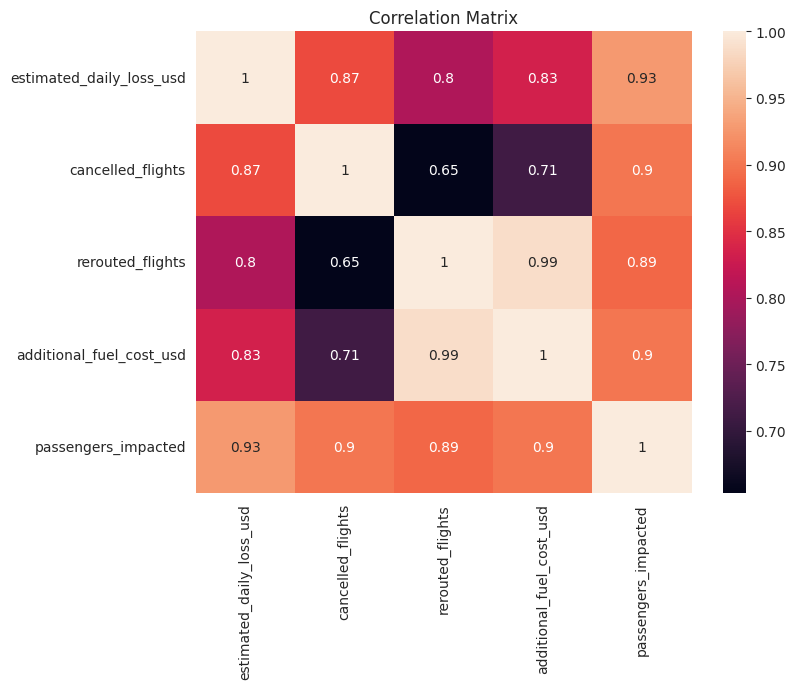

In [84]:
plt.figure(figsize=(8,6))
sns.heatmap(loss.corr(numeric_only=True),annot=True)
plt.title("Correlation Matrix")
plt.show()

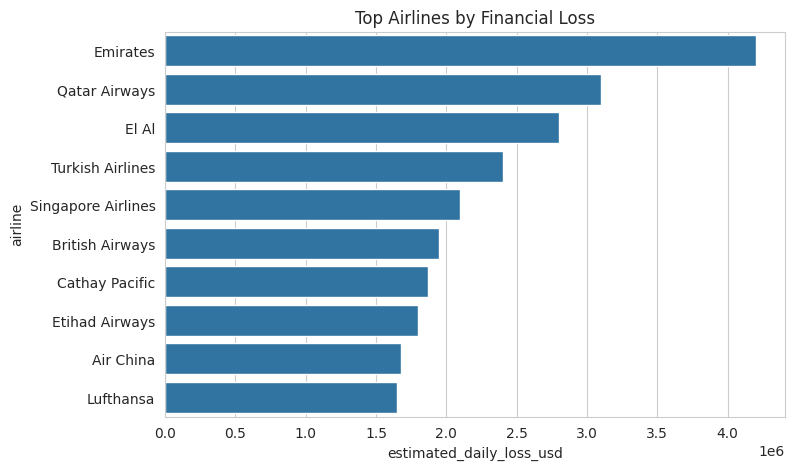

In [85]:
top = loss.sort_values("estimated_daily_loss_usd",ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(data=top,x="estimated_daily_loss_usd",y="airline")
plt.title("Top Airlines by Financial Loss")
plt.show()

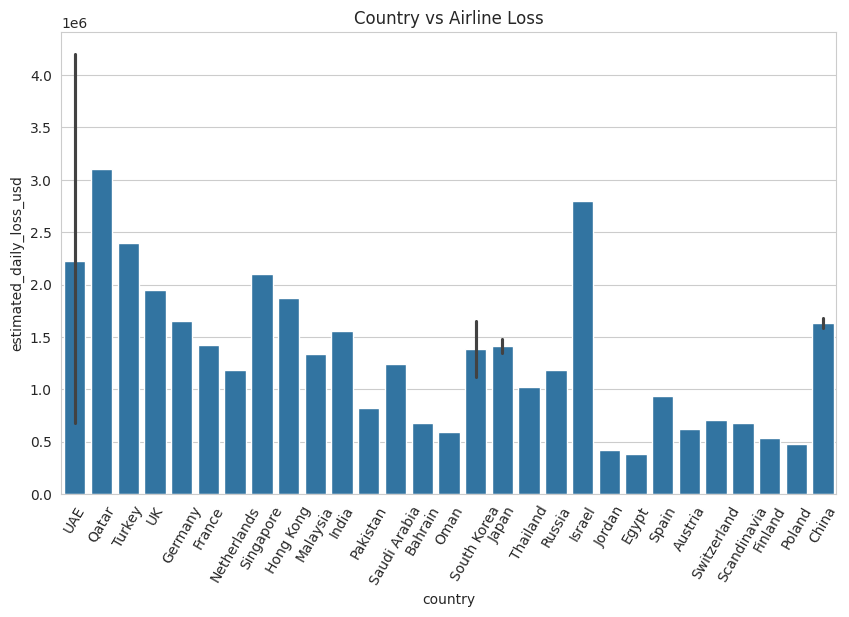

In [86]:
plt.figure(figsize=(10,6))
sns.barplot(data=loss,x="country",y="estimated_daily_loss_usd")
plt.xticks(rotation=60)
plt.title("Country vs Airline Loss")
plt.show()


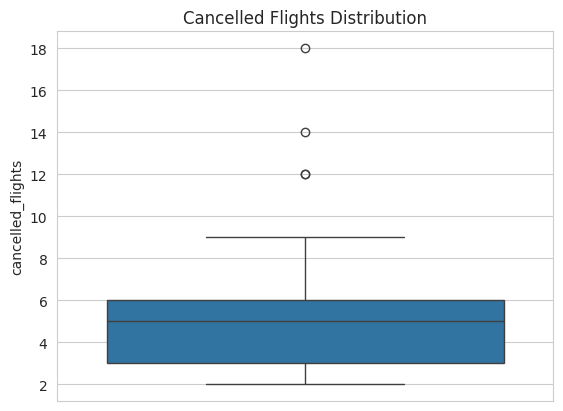

In [87]:
plt.figure()
sns.boxplot(loss["cancelled_flights"])
plt.title("Cancelled Flights Distribution")
plt.show()

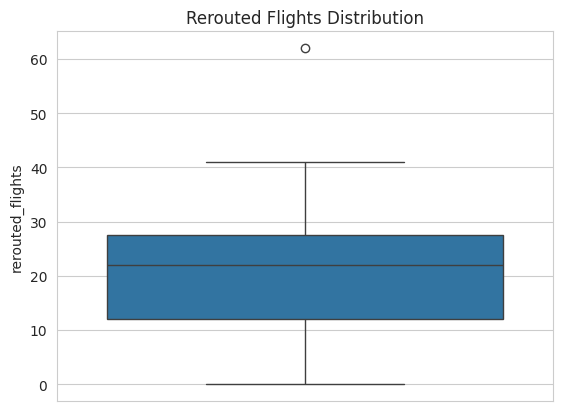

In [88]:
plt.figure()
sns.boxplot(loss["rerouted_flights"])
plt.title("Rerouted Flights Distribution")
plt.show()

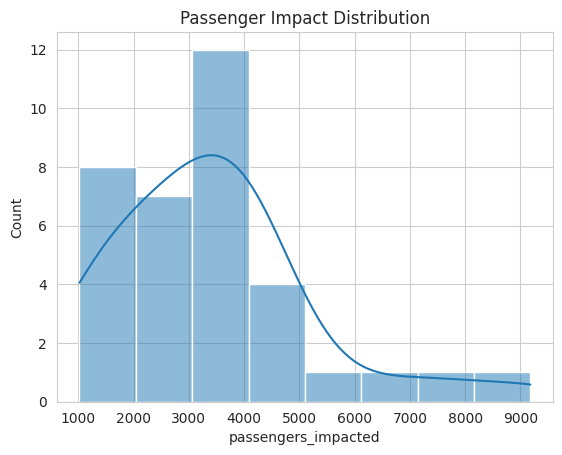

In [89]:
plt.figure()
sns.histplot(loss["passengers_impacted"],kde=True)
plt.title("Passenger Impact Distribution")
plt.show()

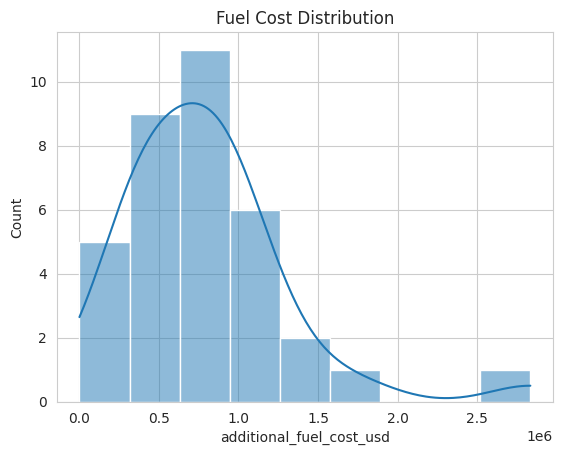

In [90]:
plt.figure()
sns.histplot(loss["additional_fuel_cost_usd"],kde=True)
plt.title("Fuel Cost Distribution")
plt.show()

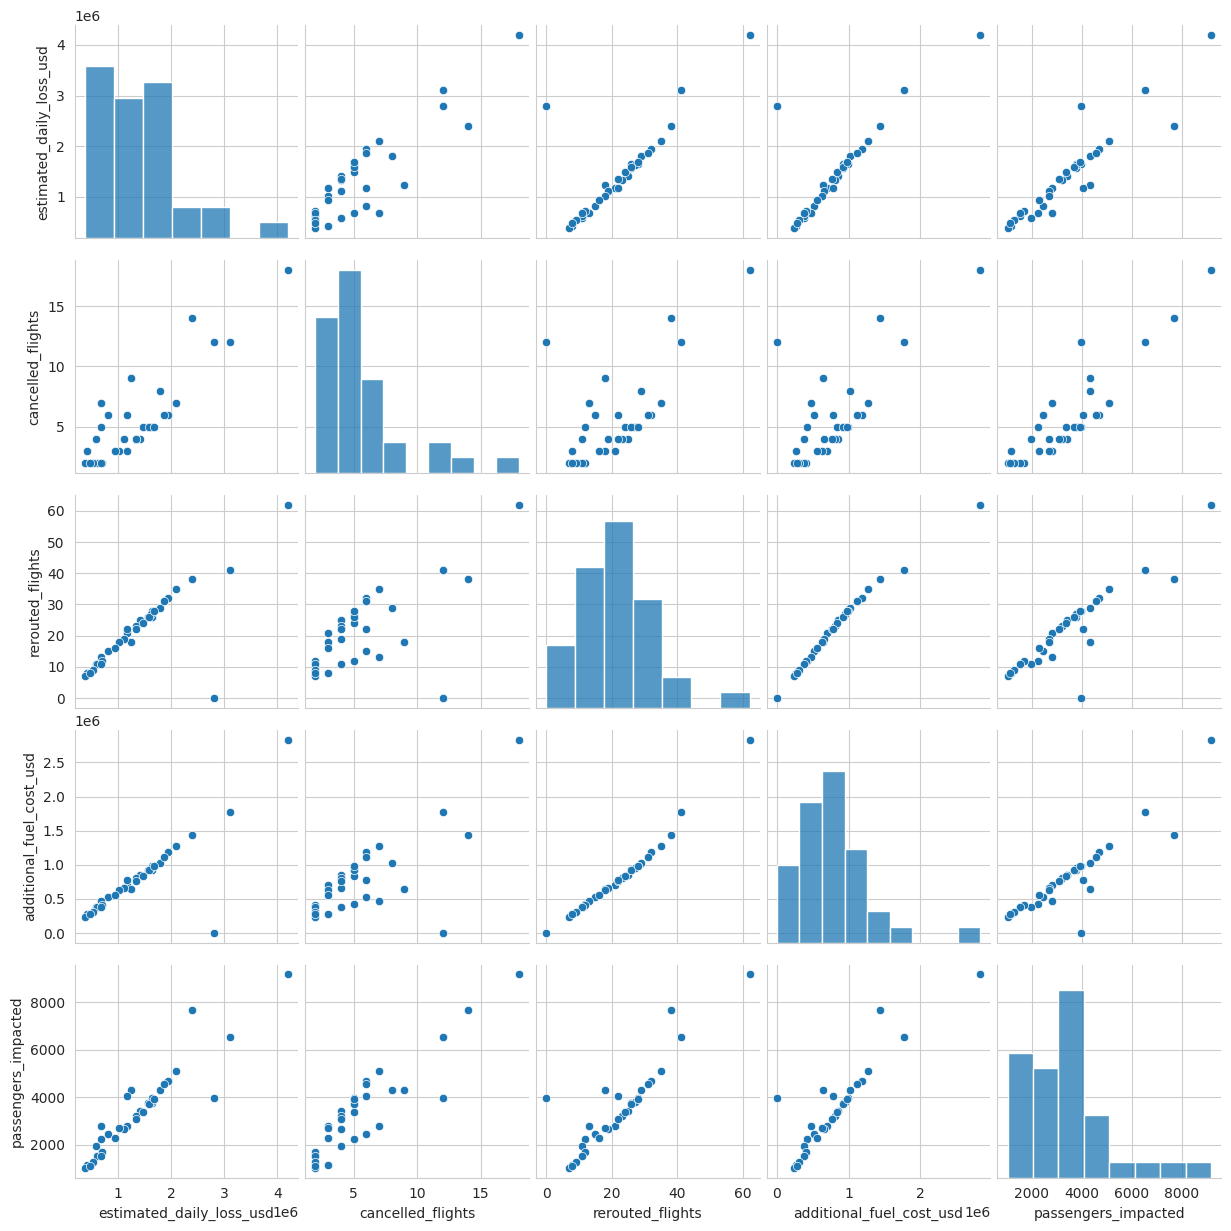

In [91]:
sns.pairplot(loss.select_dtypes(include=np.number))
plt.show()

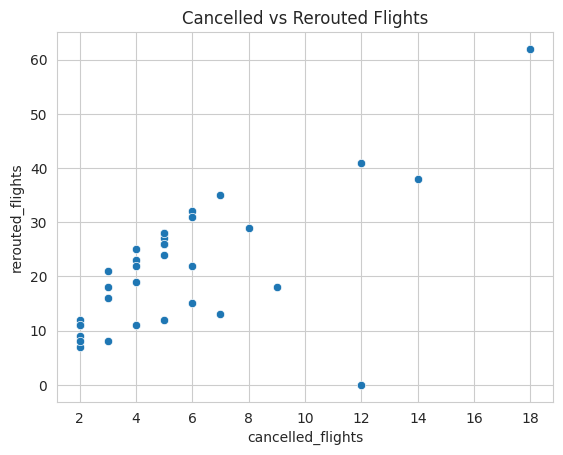

In [92]:
plt.figure()
sns.scatterplot(x=loss["cancelled_flights"],y=loss["rerouted_flights"])
plt.title("Cancelled vs Rerouted Flights")
plt.show()

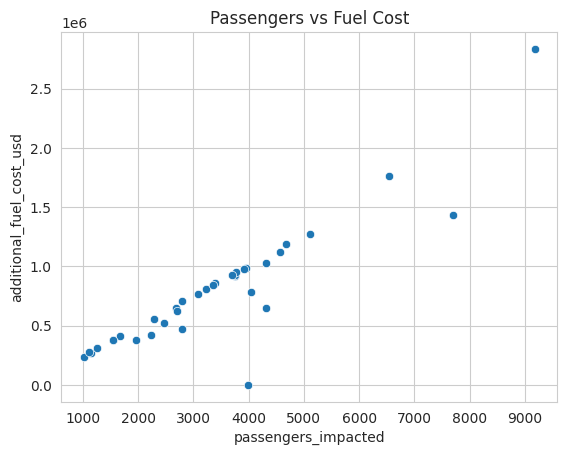

In [93]:
plt.figure()
sns.scatterplot(x=loss["passengers_impacted"],y=loss["additional_fuel_cost_usd"])
plt.title("Passengers vs Fuel Cost")
plt.show()

In [94]:
ranking = loss.sort_values("estimated_daily_loss_usd",ascending=False)
print("\nTop 10 Airlines Most Impacted")
print(ranking[["airline","country","estimated_daily_loss_usd"]].head(10))


Top 10 Airlines Most Impacted
               airline    country  estimated_daily_loss_usd
0             Emirates        UAE                   4200000
1        Qatar Airways      Qatar                   3100000
23               El Al     Israel                   2800000
3     Turkish Airlines     Turkey                   2400000
8   Singapore Airlines  Singapore                   2100000
4      British Airways         UK                   1950000
9       Cathay Pacific  Hong Kong                   1870000
2       Etihad Airways        UAE                   1800000
34           Air China      China                   1680000
5            Lufthansa    Germany                   1650000


##  AIRSPACE CLOSURE MAP

In [95]:
if "country" in airspace.columns:

    fig = px.choropleth(
        airspace,
        locations="country",
        locationmode="country names",
        title="Airspace Closures During Conflict"
    )

    fig.show()

## MACHINE LEARNING

In [96]:
X = loss[[
    "cancelled_flights",
    "rerouted_flights",
    "additional_fuel_cost_usd",
    "passengers_impacted"
]]

y = loss["estimated_daily_loss_usd"]

# Train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# Model
model = RandomForestRegressor(n_estimators=300)

In [97]:
model = RandomForestRegressor(n_estimators=300)

## CROSS VALIDATION

In [98]:
cv_scores = cross_val_score(model,X,y,cv=5,scoring="r2")

print("\nCross Validation R2 Scores:",cv_scores)
print("Mean CV Score:",cv_scores.mean())


Cross Validation R2 Scores: [0.14380639 0.96635942 0.89773151 0.20582686 0.98793432]
Mean CV Score: 0.640331700319842


## TRAIN MODEL

In [99]:
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("\nTest R2:",r2_score(y_test,pred))
print("MAE:",mean_absolute_error(y_test,pred))


Test R2: 0.945372095569804
MAE: 73223.80952380951


## FEATURE IMPORTANCE

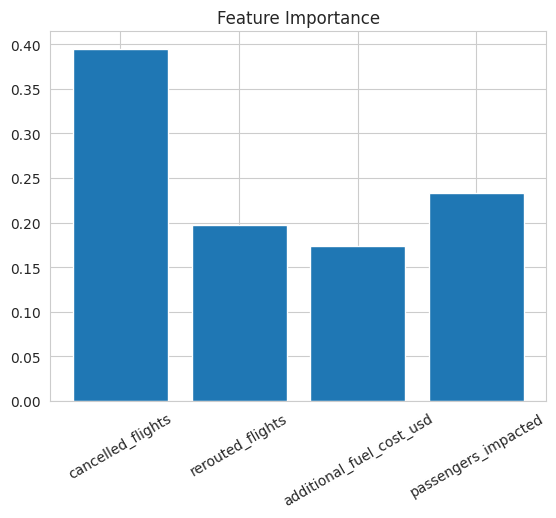

In [100]:
importance = model.feature_importances_

plt.figure()
plt.bar(X.columns,importance)
plt.title("Feature Importance")
plt.xticks(rotation=30)
plt.show()

## SHAP EXPLAINABLE AI


SHAP Summary Plot


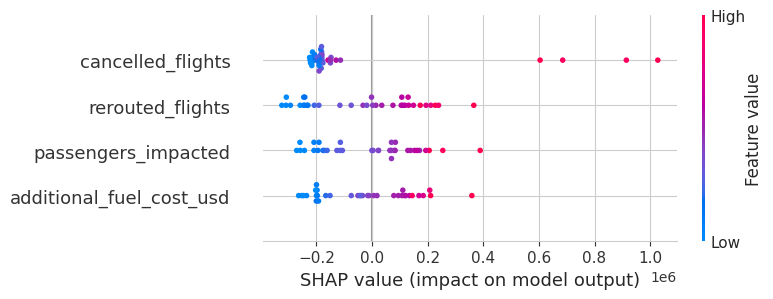


SHAP Feature Importance


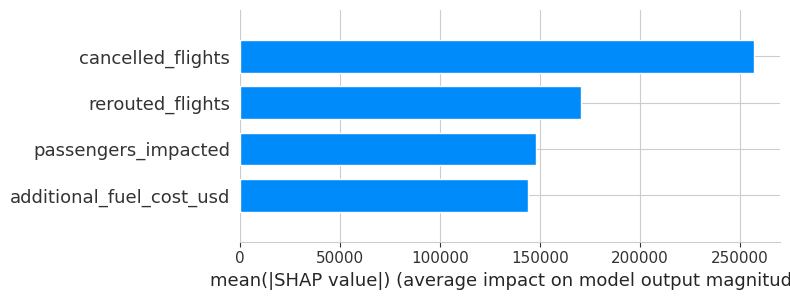

In [101]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print("\nSHAP Summary Plot")
shap.summary_plot(shap_values,X)

print("\nSHAP Feature Importance")
shap.summary_plot(shap_values,X,plot_type="bar")

# Predicting Economic Impact of Airspace Closures on Global Airlines Using Machine Learning

In [102]:


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error



df = pd.read_csv("/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/airline_losses_estimate.csv")

print("Dataset Shape:", df.shape)
print(df.head())



X = df[[
    "cancelled_flights",
    "rerouted_flights",
    "additional_fuel_cost_usd",
    "passengers_impacted"
]]

y = df["estimated_daily_loss_usd"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    # Cross Validation
    cv = cross_val_score(model, X, y, cv=5, scoring="r2").mean()

    results.append([name, r2, mae, cv])



results_df = pd.DataFrame(results, columns=["Model","R2 Score","MAE","CV R2"])
print("\nModel Comparison")
print(results_df)



best_model = RandomForestRegressor(n_estimators=300, random_state=42)
best_model.fit(X, y)




Dataset Shape: (35, 7)
            airline country  estimated_daily_loss_usd  cancelled_flights  \
0          Emirates     UAE                   4200000                 18   
1     Qatar Airways   Qatar                   3100000                 12   
2    Etihad Airways     UAE                   1800000                  8   
3  Turkish Airlines  Turkey                   2400000                 14   
4   British Airways      UK                   1950000                  6   

   rerouted_flights  additional_fuel_cost_usd  passengers_impacted  
0                62                   2835200                 9180  
1                41                   1765800                 6540  
2                29                   1023400                 4320  
3                38                   1432600                 7700  
4                32                   1185600                 4680  

Model Comparison
               Model  R2 Score            MAE     CV R2
0  Linear Regression  0.318927  

RandomForestRegressor(n_estimators=300, random_state=42)

# Predicting Economic Impact of Airspace Closures on Global Airlines Using Machine Learning

In [103]:


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error



df = pd.read_csv("/kaggle/input/datasets/zkskhurram/global-civil-aviation-disruption2026-iranus-war/airline_losses_estimate.csv")

print("Dataset Shape:", df.shape)
print(df.head())



X = df[[
    "cancelled_flights",
    "rerouted_flights",
    "additional_fuel_cost_usd",
    "passengers_impacted"
]]

y = df["estimated_daily_loss_usd"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    # Cross Validation
    cv = cross_val_score(model, X, y, cv=5, scoring="r2").mean()

    results.append([name, r2, mae, cv])



results_df = pd.DataFrame(results, columns=["Model","R2 Score","MAE","CV R2"])
print("\nModel Comparison")
print(results_df)



best_model = RandomForestRegressor(n_estimators=300, random_state=42)
best_model.fit(X, y)




Dataset Shape: (35, 7)
            airline country  estimated_daily_loss_usd  cancelled_flights  \
0          Emirates     UAE                   4200000                 18   
1     Qatar Airways   Qatar                   3100000                 12   
2    Etihad Airways     UAE                   1800000                  8   
3  Turkish Airlines  Turkey                   2400000                 14   
4   British Airways      UK                   1950000                  6   

   rerouted_flights  additional_fuel_cost_usd  passengers_impacted  
0                62                   2835200                 9180  
1                41                   1765800                 6540  
2                29                   1023400                 4320  
3                38                   1432600                 7700  
4                32                   1185600                 4680  

Model Comparison
               Model  R2 Score            MAE     CV R2
0  Linear Regression  0.318927  

RandomForestRegressor(n_estimators=300, random_state=42)

In [104]:

import joblib


joblib.dump(best_model, "airline_loss_model.pkl")

print("Model saved as airline_loss_model.pkl")

Model saved as airline_loss_model.pkl
